# CBSA City Profiles

Two functions for per-city analysis:

1. **`plot_degree_distribution(cbsa_code)`** — histogram of node degree for each decade + text file of top-20 highest-degree tracts.
2. **`plot_graph(cbsa_code, overlay_shapefile=False)`** — one graph visualisation PNG per decade, with optional shapefile underlay.

In [1]:
import json
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import geopandas as gpd

YEARS                  = [1980, 1990, 2000, 2010, 2020]
CBSA_DIR               = 'study_areas'
CENSUS_GEOGRAPHY_TYPE  = 'tracts'   # 'tracts' or 'block_groups'
VINTAGE                = None       # None = all vintages; set e.g. 'march_2020' to restrict
OUT_DIR                = 'figures/city_profiles'

SCORE_CSV_DIR = 'outputs/tracts_in_cbsa_2020-2010-2000-1990-1980_years_march_2020_vintage'

_cbsa_df = pd.read_csv('cbsas.csv')
cbsa_dict = dict(zip(_cbsa_df['CBSA Code'], _cbsa_df['CBSA Name']))

In [2]:
def find_files(cbsa_code, vintage=VINTAGE):
    """
    Return {year: filepath} for every decade that has a connected JSON for this CBSA.
    Files: study_areas/{year}/{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_{code}_{year}_{vintage}_vintage_connected.json
    """
    found = {}
    for yr in YEARS:
        pattern = os.path.join(
            CBSA_DIR, str(yr),
            f'{CENSUS_GEOGRAPHY_TYPE}_in_cbsa_{cbsa_code}_{yr}_*_vintage_connected.json'
        )
        matches = sorted(glob.glob(pattern))
        if vintage:
            matches = [m for m
             in matches if vintage in os.path.basename(m)]
        if matches:
            found[yr] = matches[0]
    return found


def load_graph(filepath):
    """
    Load a connected JSON and return (nodes_dict, nx.Graph).
    nodes_dict: {node_id: attribute_dict}
    Graph nodes are keyed by their 'id' attribute to stay consistent
    with the adjacency references.
    """
    with open(filepath) as f:
        d = json.load(f)
    nodes_list = d['nodes']

    nodes = {node['id']: node for node in nodes_list}
    G = nx.Graph()
    for node_id, attrs in nodes.items():
        G.add_node(node_id, **attrs)

    for i, neighbours in enumerate(d['adjacency']):
        src_id = nodes_list[i]['id']
        for nb in neighbours:
            j = nb['id']
            if src_id < j:
                G.add_edge(src_id, j, shared_perim=nb.get('shared_perim', 1))

    return nodes, G

In [3]:
def plot_degree_distribution(cbsa_code, vintage=VINTAGE, out_dir=OUT_DIR):
    """
    For each available decade, plot the degree distribution of the CBSA graph.
    Produces a 3-row figure (all / ≤ Tukey threshold / ≥ Tukey threshold).
    Also writes a text file listing the top-20 highest-degree tracts, and
    prints per-year leaf counts and degree summary statistics.
    """
    files = find_files(cbsa_code, vintage=vintage)
    if not files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    years = sorted(files)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    # Load all graphs once
    graphs_by_year = {}
    nodes_by_year = {}
    degrees_by_year = {}
    for yr in years:
        n, G = load_graph(files[yr])
        graphs_by_year[yr] = G
        nodes_by_year[yr] = n
        degrees_by_year[yr] = dict(G.degree())

    # Tukey upper fence from pooled degrees across all years
    all_degrees_flat = [d for yr in years for d in degrees_by_year[yr].values()]
    q1, q3 = np.percentile(all_degrees_flat, [25, 75])
    threshold = q3 + 1.5 * (q3 - q1)
    max_deg_all = max(all_degrees_flat)

    # 3-row figure
    fig, axes = plt.subplots(3, len(years), figsize=(4 * len(years), 3.5 * 3), squeeze=False)
    fig.suptitle(f'Degree Distribution — {cbsa_name}', fontsize=14, fontweight='bold', y=1.02)

    row_labels = [
        f'All  (threshold={threshold:.1f})',
        f'Degree ≤ {threshold:.1f}',
        f'Degree ≥ {threshold:.1f}',
    ]

    for col, yr in enumerate(years):
        vals_all = list(degrees_by_year[yr].values())
        vals_below = [d for d in vals_all if d <= threshold]
        vals_above = [d for d in vals_all if d >= threshold]

        for row, vals in enumerate([vals_all, vals_below, vals_above]):
            ax = axes[row][col]

            if row == 0:
                bins = range(0, max_deg_all + 2)
            elif row == 1:
                bins = range(0, int(threshold) + 2)
            else:
                bins = range(int(threshold), (max(vals) if vals else int(threshold)) + 2)

            if vals:
                ax.hist(vals, bins=bins, color='steelblue', edgecolor='white', linewidth=0.4, alpha=0.85)
            if col == 0:
                ax.set_ylabel(row_labels[row], fontsize=9)
            else:
                ax.set_yticklabels([])
            if row == 0:
                ax.set_title(str(yr), fontsize=12, fontweight='bold')
            ax.set_xlabel('Degree', fontsize=9)
            ax.tick_params(labelsize=8)
            ax.text(0.97, 0.95, f'n={len(vals):,}', transform=ax.transAxes,
                    ha='right', va='top', fontsize=8, color='#555')
            if vals:
                ax.text(0.97, 0.85, f'med={np.median(vals):.1f}', transform=ax.transAxes,
                        ha='right', va='top', fontsize=8, color='#555')

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_degree_dist.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved {fig_path}')
    plt.show()

    # Text report: top-20 highest-degree tracts per year
    text_lines = [f'{cbsa_name} — Degree Distribution Report', '=' * 60]
    for yr in years:
        degrees = degrees_by_year[yr]
        nodes = nodes_by_year[yr]
        text_lines += ['', f'{yr}  |  {os.path.basename(files[yr])}']
        top20 = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:20]
        text_lines.append(f'  {"Rank":>4}  {"Degree":>6}  Tract')
        text_lines.append(f'  {"-"*55}')
        for rank, (node_id, deg) in enumerate(top20, 1):
            attrs = nodes.get(node_id, {})
            tract_label = attrs.get('NAME') or attrs.get('GEOID') or attrs.get('GISJOIN', str(node_id))
            text_lines.append(f'  {rank:>4}  {deg:>6}  {tract_label}')
    txt_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_degree_report.txt')
    with open(txt_path, 'w') as f:
        f.write('\n'.join(text_lines) + '\n')
    print(f'Saved {txt_path}')

    # Stats printout
    print(f'\nDegree statistics by year — {cbsa_name}  (Tukey threshold = {threshold:.1f})')
    print(f"{'Year':>6}  {'Leaves':>7}  {'Mean':>8}  {'Median':>8}  {'Min':>5}  {'Max':>5}  {'Std':>8}")
    print('-' * 60)
    for yr in years:
        arr = np.array(list(degrees_by_year[yr].values()))
        n_leaves = int((arr == 1).sum())
        print(f"{yr:>6}  {n_leaves:>7}  {arr.mean():>8.2f}  {np.median(arr):>8.2f}  "
              f"{int(arr.min()):>5}  {int(arr.max()):>5}  {arr.std():>8.2f}")

In [4]:
def _node_positions(G):
    """
    Return {node_id: (x, y)} from centroid_x / centroid_y stored on graph nodes.
    Falls back to spring layout only if no centroids are found at all.
    Nodes missing centroids are placed at the mean centroid to avoid scale mismatch.
    """
    pos = {}
    missing = []
    for node_id, attrs in G.nodes(data=True):
        cx = attrs.get('centroid_x')
        cy = attrs.get('centroid_y')
        if cx is not None and cy is not None:
            pos[node_id] = (cx, cy)
        else:
            missing.append(node_id)

    if not pos:
        print('  centroid_x/centroid_y not found on any nodes — falling back to spring layout')
        return nx.spring_layout(G, seed=42)

    if missing:
        print(f'  Warning: {len(missing)} nodes missing centroid attrs — placing at mean centroid')
        mean_x = sum(x for x, y in pos.values()) / len(pos)
        mean_y = sum(y for x, y in pos.values()) / len(pos)
        for node_id in missing:
            pos[node_id] = (mean_x, mean_y)

    return pos


def _moran_p(G, arr):
    """
    Moran's I with row-standardized adjacency weights (the 'P' matrix).
    arr must be ordered to match list(G.nodes()).
    Returns nan if the graph has fewer than 2 nodes or no variation.
    """
    if len(G) < 2:
        return np.nan
    nodelist = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodelist)
    row_sums = A.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    P = A / row_sums
    x = arr.astype(float) - arr.mean()
    denom = float(x @ x)
    if denom == 0:
        return np.nan
    return float(x @ P @ x) / denom


def _compute_var(G, var):
    """
    Return a float array of per-node values for var.
    Handles derived variables 'Black_Share' and 'Poc_Share' in addition to
    raw node attributes.
    """
    raw = []
    for i in G.nodes():
        attrs = G.nodes[i]
        if var == 'Black_Share':
            denom = (attrs.get('BLACK') or 0) + (attrs.get('WHITE') or 0)
            val = (attrs.get('BLACK') or 0) / denom if denom > 0 else np.nan
        elif var == 'Poc_Share':
            totpop = attrs.get('TOTPOP') or 0
            val = (attrs.get('POC') or 0) / totpop if totpop > 0 else np.nan
        else:
            val = attrs.get(var, 0) or 0
        raw.append(val)
    return np.array(raw, dtype=float)


def plot_graph(cbsa_code, overlay_shapefile=False, var=None, vintage=VINTAGE, out_dir=OUT_DIR):
    """
    Plot a graph visualisation of the CBSA for each available decade.
    Nodes are positioned at their centroid_x / centroid_y coordinates (esri:102003).
    Saves one PNG per decade.

    Parameters
    ----------
    overlay_shapefile : bool
        If True, draw the source shapefile polygons as a grey underlay.
    var : str or None
        Node attribute to colour by. If None, all nodes are drawn in a uniform
        colour. Available attributes come from the connected JSON node data:
        e.g. 'TOTPOP', 'WHITE', 'BLACK', 'POC'.
        Two derived variables are also available:
          'Black_Share' — BLACK / (BLACK + WHITE)
          'Poc_Share'   — POC / TOTPOP
        When var is set, Moran's P is computed and shown in the summary table.
    """
    files = find_files(cbsa_code, vintage=vintage)
    if not files:
        print(f'No files found for CBSA {cbsa_code}')
        return

    os.makedirs(out_dir, exist_ok=True)
    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))
    year_stats = {}
    year_moran = {}

    for yr in sorted(files):
        fp = files[yr]
        nodes, G = load_graph(fp)

        pos = _node_positions(G)

        fig, ax = plt.subplots(figsize=(10, 10))
        ax.set_title(
            f'{cbsa_name} — {yr}  ({G.number_of_nodes()} tracts, {G.number_of_edges()} edges)',
            fontsize=13, fontweight='bold')

        # shapefile underlay — load in esri:102003 to match stored centroid coords
        if overlay_shapefile:
            shp_path = fp.replace('_connected.json', '.shp')
            if os.path.exists(shp_path):
                gdf = gpd.read_file(shp_path).to_crs('esri:102003')
                gdf.plot(ax=ax, color='#f0f0f0', edgecolor='#aaaaaa', linewidth=0.5)
            else:
                print(f'  Shapefile not found: {shp_path}')

        node_sizes = [10] * G.number_of_nodes()

        nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.6, edge_color='#888')

        if var is not None:
            arr = _compute_var(G, var)
            year_stats[yr] = arr
            year_moran[yr] = _moran_p(G, arr)
            min_v, max_v = np.nanmin(arr), np.nanmax(arr)
            span = max_v - min_v if max_v != min_v else 1
            node_colors = ((arr - min_v) / span).tolist()
            nc = nx.draw_networkx_nodes(G, pos, ax=ax,
                                        node_color=node_colors, cmap=plt.cm.plasma,
                                        node_size=node_sizes, alpha=0.85)
            plt.colorbar(nc, ax=ax, label=f'{var} (normalised)', shrink=0.6)
        else:
            nx.draw_networkx_nodes(G, pos, ax=ax,
                                   node_color='steelblue',
                                   node_size=node_sizes, alpha=0.85)

        ax.set_axis_off()
        plt.tight_layout()

        mode = 'overlay' if overlay_shapefile else 'graph'
        var_tag = f'_{var}' if var is not None else ''
        fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_{yr}{var_tag}_{mode}.png')
        fig.savefig(fig_path, dpi=150, bbox_inches='tight')
        print(f'Saved {fig_path}')
        plt.show()

    # Per-year stats for var
    if var is not None and year_stats:
        print(f'\n{var} statistics by year — {cbsa_name}')
        print(f"{'Year':>6}  {'Mean':>12}  {'Median':>12}  {'Min':>12}  {'Max':>12}  {'Std':>12}  {'Moran P':>9}")
        print('-' * 83)
        for yr, arr in sorted(year_stats.items()):
            mp = year_moran.get(yr, np.nan)
            mp_str = f'{mp:>9.4f}' if not np.isnan(mp) else f'{"n/a":>9}'
            print(f"{yr:>6}  {np.nanmean(arr):>12.2f}  {np.nanmedian(arr):>12.2f}  "
                  f"{np.nanmin(arr):>12.2f}  {np.nanmax(arr):>12.2f}  {np.nanstd(arr):>12.2f}  {mp_str}")

In [5]:
import re as _re

def _metric_label(col):
    """Return a human-readable label for a metric column name."""

    def _lam(s):
        return '∞' if s == 'lim' else s

    _moran_map = {
        'A':   'Adjacency',
        'P':   'Row Standardized Adjacency',
        'M':   'Metropolis',
        'L':   'Laplacian',
        'D_1': 'Inverse Distance',
        'D_2': 'Inverse Distance 2',
    }

    # Assortativity
    if col == 'e_assort':
        return 'Assortativity-Edge Count'
    if col == 'he_assort':
        return 'Assortativity-Halfedge Count'

    # Dissimilarity
    m = _re.fullmatch(r"dissimilarity_(\d+)", col)
    if m:
        p = m.group(1)
        if p == '1':
            return 'Dissimilarity'
        return f'Dissimilarity (P = {p})'

    # Moran's I
    m = _re.fullmatch(r"moran_(.+)", col)
    if m:
        key = m.group(1)
        return f"Moran's I ({_moran_map.get(key, key)})"

    # Half Edge (exact)
    m = _re.fullmatch(r"half_edge_exact_(.+)", col)
    if m:
        return f"Half Edge Exact (λ={_lam(m.group(1))})"

    # Half Edge
    m = _re.fullmatch(r"half_edge_(.+)", col)
    if m:
        return f"Half Edge (λ={_lam(m.group(1))})"

    # Edge (exact)
    m = _re.fullmatch(r"edge_exact_(.+)", col)
    if m:
        return f"Edge Exact (λ={_lam(m.group(1))})"

    # Edge
    m = _re.fullmatch(r"edge_(.+)", col)
    if m:
        return f"Edge (λ={_lam(m.group(1))})"

    # Skew' (exact)
    m = _re.fullmatch(r"skew'_(self|other)_exact_(.+)", col)
    if m:
        return f"Skew' ({m.group(1).title()} Exact, λ={_lam(m.group(2))})"

    # Skew'
    m = _re.fullmatch(r"skew'_(self|other)_(.+)", col)
    if m:
        return f"Skew' ({m.group(1).title()}, λ={_lam(m.group(2))})"

    # Skew (exact)
    m = _re.fullmatch(r"skew_(self|other)_exact_(.+)", col)
    if m:
        return f"Skew ({m.group(1).title()} Exact, λ={_lam(m.group(2))})"

    # Skew
    m = _re.fullmatch(r"skew_(self|other)_(.+)", col)
    if m:
        return f"Skew ({m.group(1).title()}, λ={_lam(m.group(2))})"

    return col  # fallback: return column name unchanged


def plot_score_graph(cbsa_code, metrics, out_dir=OUT_DIR, csv_dir=SCORE_CSV_DIR):
    """
    Plot selected metrics over time for a given CBSA.
    Produces two line plots side-by-side: one for white_black, one for white_poc.

    Parameters
    ----------
    cbsa_code : int
        CBSA code to plot.
    metrics : list of str
        Column names to plot, e.g. ['dissimilarity_1', 'gini', 'moran_P'].
    """
    csv_files = {
        'White–Black Comparison': os.path.join(csv_dir, 'white_black.csv'),
        'White–POC Comparison':   os.path.join(csv_dir, 'white_poc.csv'),
    }

    os.makedirs(out_dir, exist_ok=True)

    cbsa_name = cbsa_dict.get(cbsa_code, str(cbsa_code))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{cbsa_name} — Metrics Over Time', fontsize=14, fontweight='bold')

    subs_by_label = {}

    for ax, (label, csv_path) in zip(axes, csv_files.items()):
        if not os.path.exists(csv_path):
            ax.text(0.5, 0.5, f'File not found:\n{csv_path}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=9)
            ax.set_title(label)
            continue

        df = pd.read_csv(csv_path)

        df['cbsa_code'] = (
            df['filename']
              .str.extract(r'tracts_in_cbsa_(\d+)')[0]
              .astype(int)
        )
        df['year'] = (
            df['filename']
              .str.extract(r'tracts_in_cbsa_\d+_(\d{4})_')[0]
              .astype(int)
        )

        sub = df[df['cbsa_code'] == cbsa_code].sort_values('year')

        if sub.empty:
            ax.text(0.5, 0.5, f'No data for CBSA {cbsa_code}',
                    ha='center', va='center', transform=ax.transAxes, fontsize=10)
            ax.set_title(label)
            continue

        subs_by_label[label] = sub

        for metric in metrics:
            if metric not in sub.columns:
                print(f'  Warning: {metric!r} not in {label} CSV — skipping')
                continue
            ax.plot(sub['year'], sub[metric], marker='o', linewidth=1.8,
                    label=_metric_label(metric))

        ax.set_title(label, fontsize=12, fontweight='bold')
        ax.set_xlabel('Year', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_xticks(sub['year'].tolist())
        ax.tick_params(labelsize=9)
        ax.legend(fontsize=8, framealpha=0.7)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fig_path = os.path.join(out_dir, f'cbsa_{cbsa_code}_scores.png')
    fig.savefig(fig_path, dpi=150, bbox_inches='tight')
    print(f'Saved {fig_path}')
    plt.show()

    # Stats table per comparison group
    for label, sub in subs_by_label.items():
        available = [m for m in metrics if m in sub.columns]
        if not available:
            continue
        col_w = max(10, max(len(m) for m in available))
        print(f'\n{label}')
        header = f"{'Year':>6}"
        for m in available:
            header += f"  {m:>{col_w}}"
        print(header)
        sep = '-' * (6 + (col_w + 2) * len(available))
        print(sep)
        for _, row in sub.iterrows():
            line = f"{int(row['year']):>6}"
            for m in available:
                line += f"  {row[m]:>{col_w}.4f}"
            print(line)
        print(sep)
        for stat_name, fn in [
            ('Mean',   lambda s: s.mean()),
            ('Median', lambda s: s.median()),
            ('Min',    lambda s: s.min()),
            ('Max',    lambda s: s.max()),
            ('Std',    lambda s: s.std()),
        ]:
            line = f"{stat_name:>6}"
            for m in available:
                line += f"  {fn(sub[m]):>{col_w}.4f}"
            print(line)

## Example usage

Replace `26300` with any CBSA code from `cbsas.csv`.

In [6]:
CBSA = 16980   # example: substitute your target CBSA code


Saved figures/city_profiles/cbsa_16980_degree_dist.png


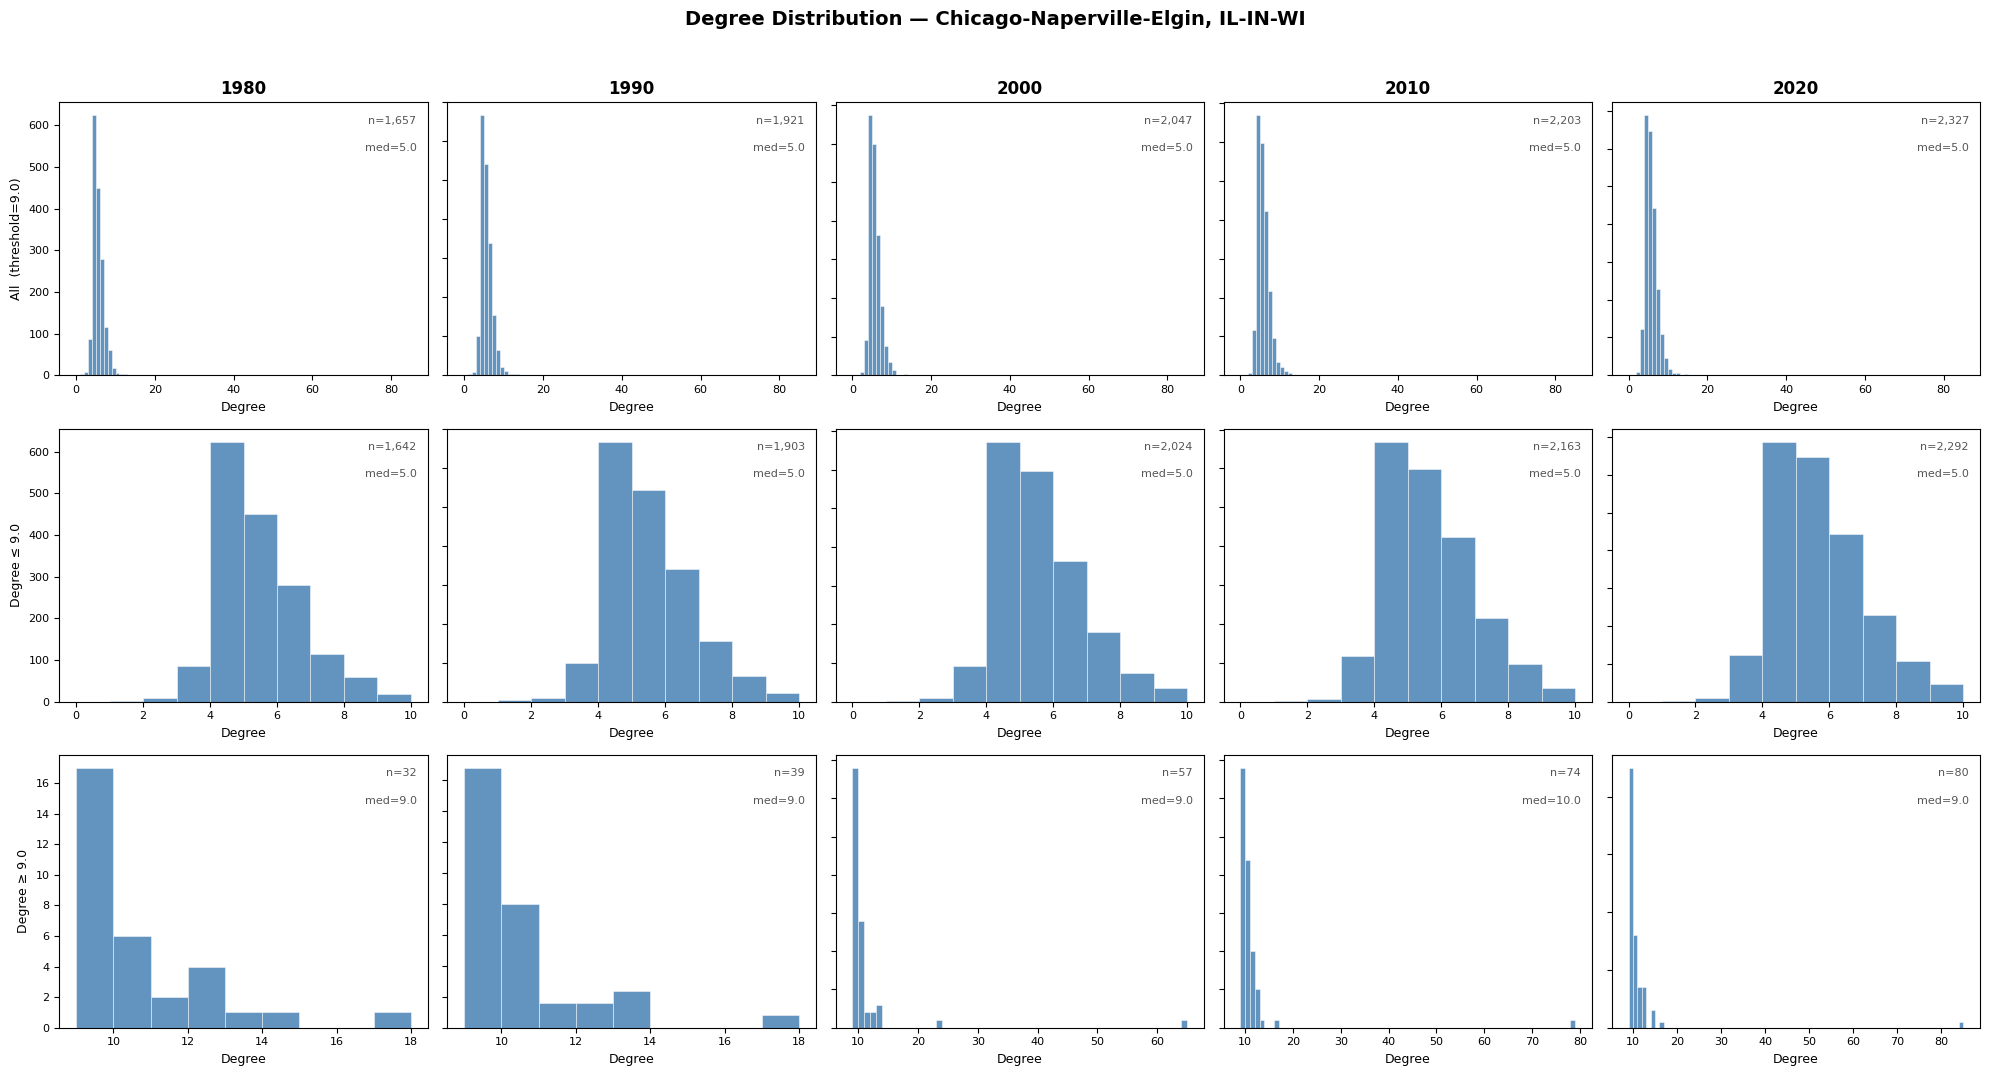

Saved figures/city_profiles/cbsa_16980_degree_report.txt

Degree statistics by year — Chicago-Naperville-Elgin, IL-IN-WI  (Tukey threshold = 9.0)
  Year   Leaves      Mean    Median    Min    Max       Std
------------------------------------------------------------
  1980        2      5.02      5.00      1     17      1.42
  1990        4      5.07      5.00      1     17      1.42
  2000        2      5.19      5.00      1     64      1.96
  2010        1      5.29      5.00      1     78      2.17
  2020        1      5.31      5.00      1     84      2.24


In [7]:

plot_degree_distribution(CBSA)

Saved figures/city_profiles/cbsa_16980_1980_Black_Share_overlay.png


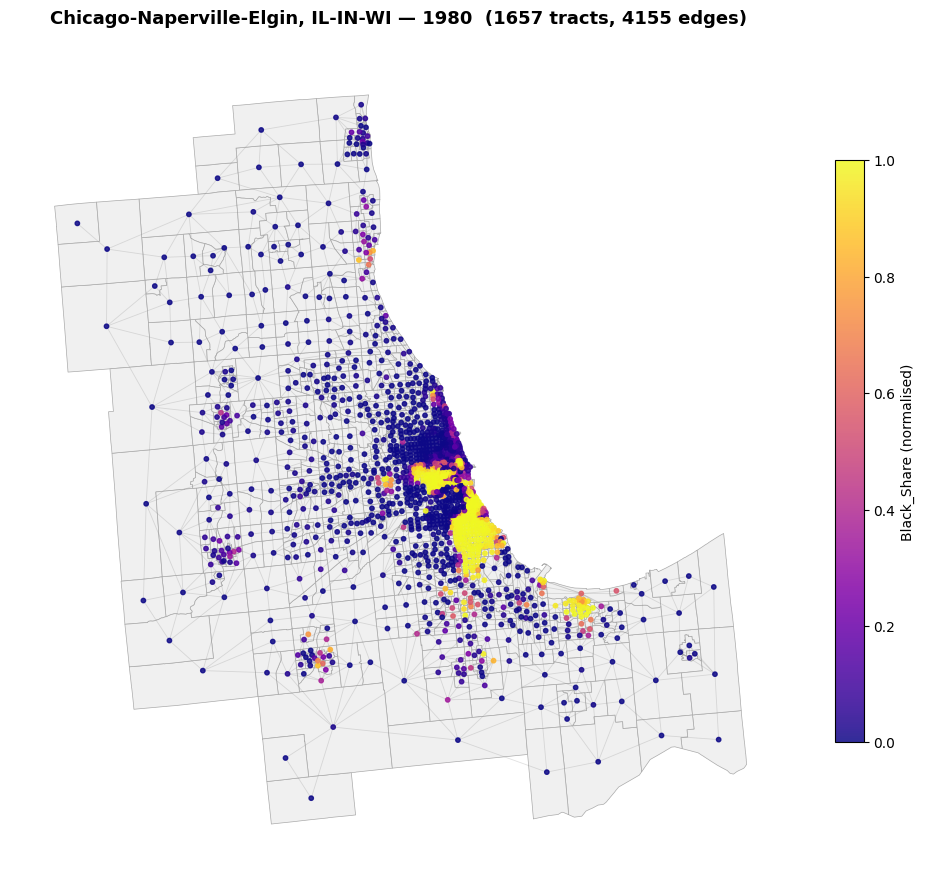

Saved figures/city_profiles/cbsa_16980_1990_Black_Share_overlay.png


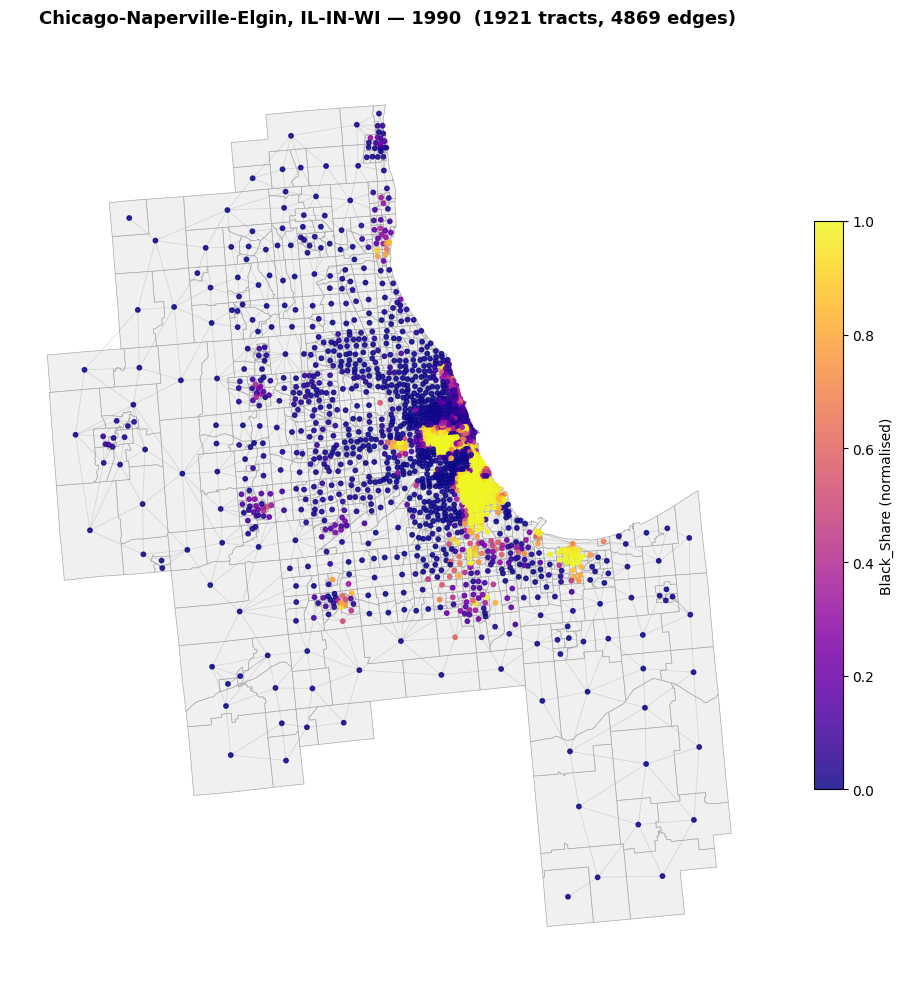

Saved figures/city_profiles/cbsa_16980_2000_Black_Share_overlay.png


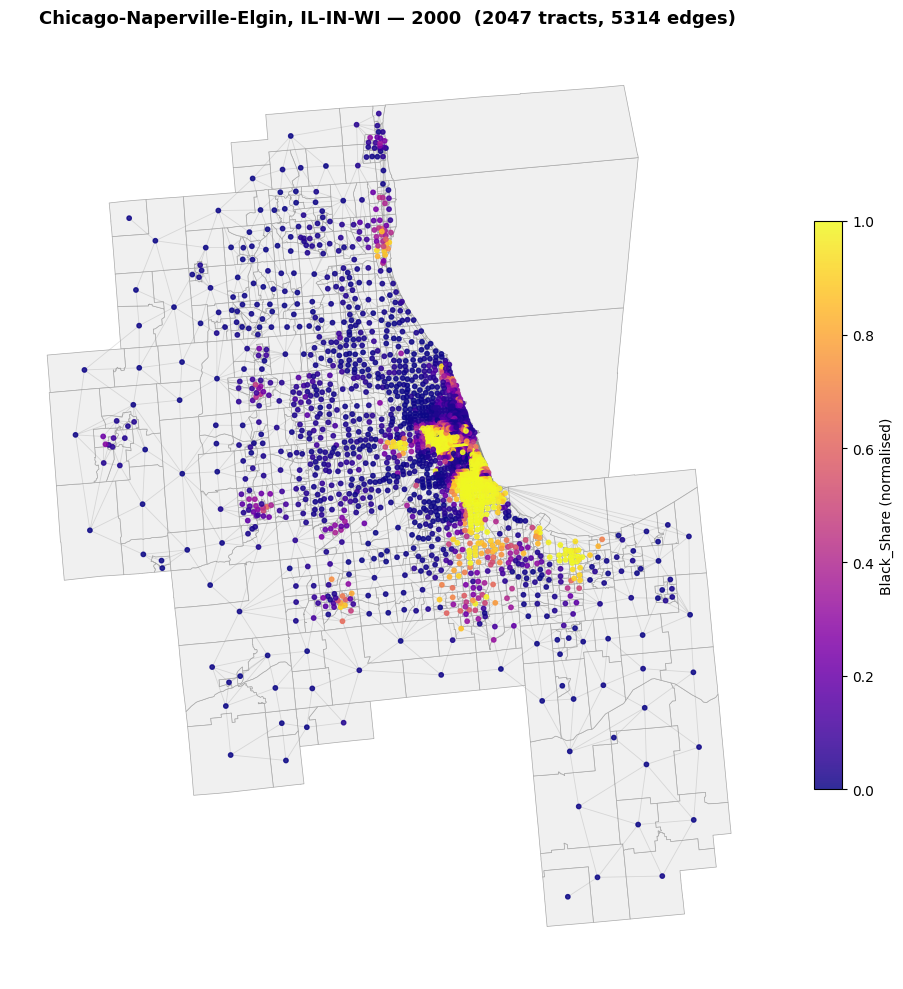

Saved figures/city_profiles/cbsa_16980_2010_Black_Share_overlay.png


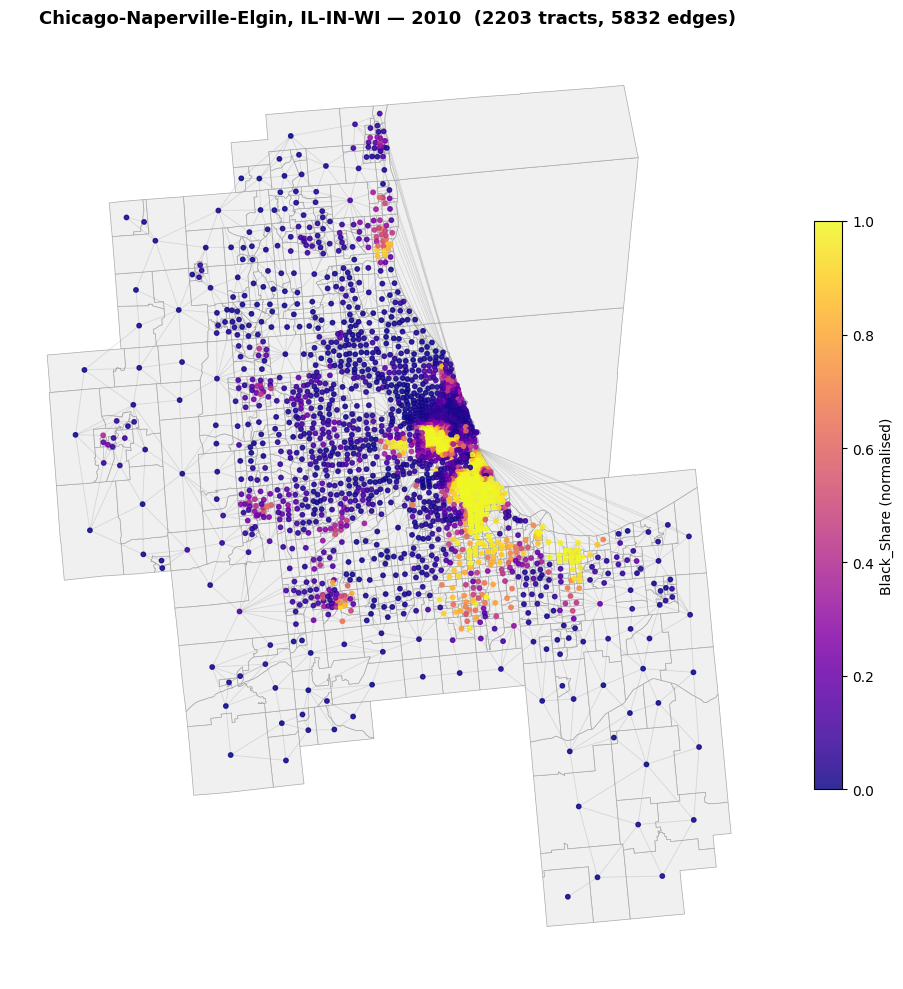

Saved figures/city_profiles/cbsa_16980_2020_Black_Share_overlay.png


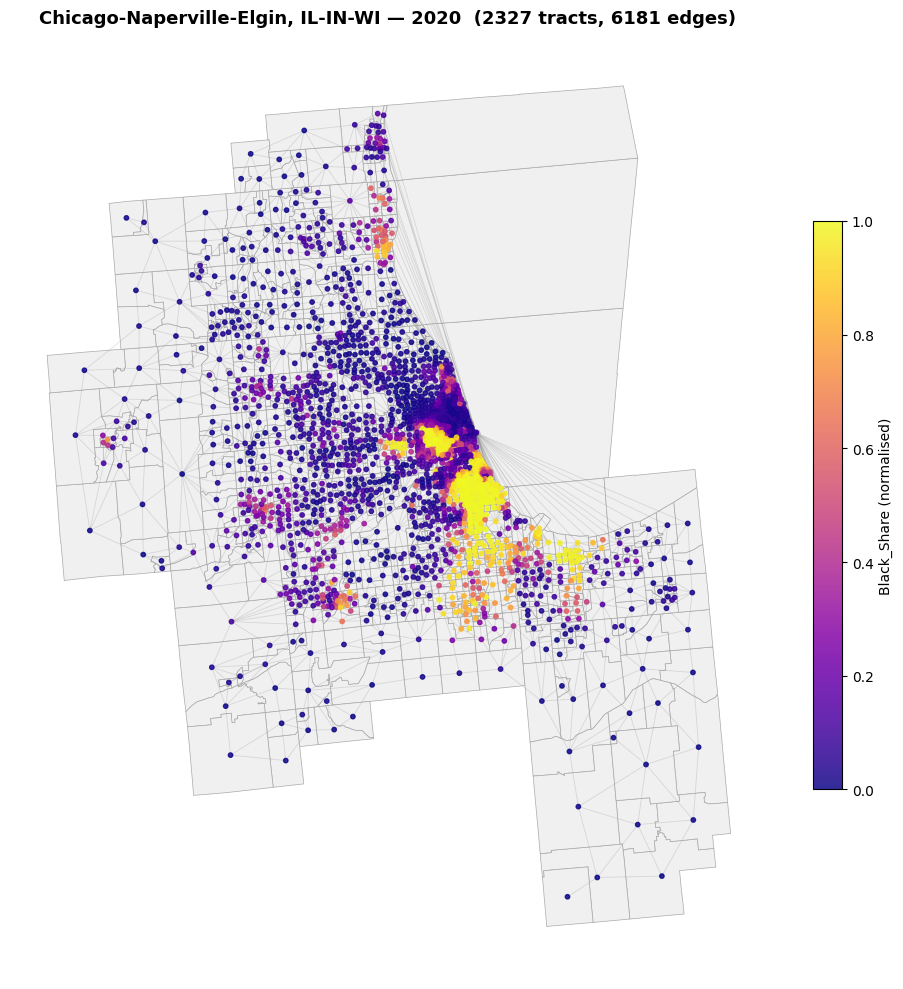


Black_Share statistics by year — Chicago-Naperville-Elgin, IL-IN-WI
  Year          Mean        Median           Min           Max           Std    Moran P
-----------------------------------------------------------------------------------
  1980          0.27          0.02          0.00          1.00          0.40     0.8345
  1990          0.28          0.03          0.00          1.00          0.39     0.8451
  2000          0.30          0.06          0.00          1.00          0.39     0.8458
  2010          0.28          0.08          0.00          1.00          0.36     0.8650
  2020          0.28          0.10          0.00          1.00          0.35     0.8708


In [8]:
# Graph without shapefile (spring layout)
plot_graph(CBSA, var = "Black_Share", overlay_shapefile=True)

Saved figures/city_profiles/cbsa_16980_scores.png


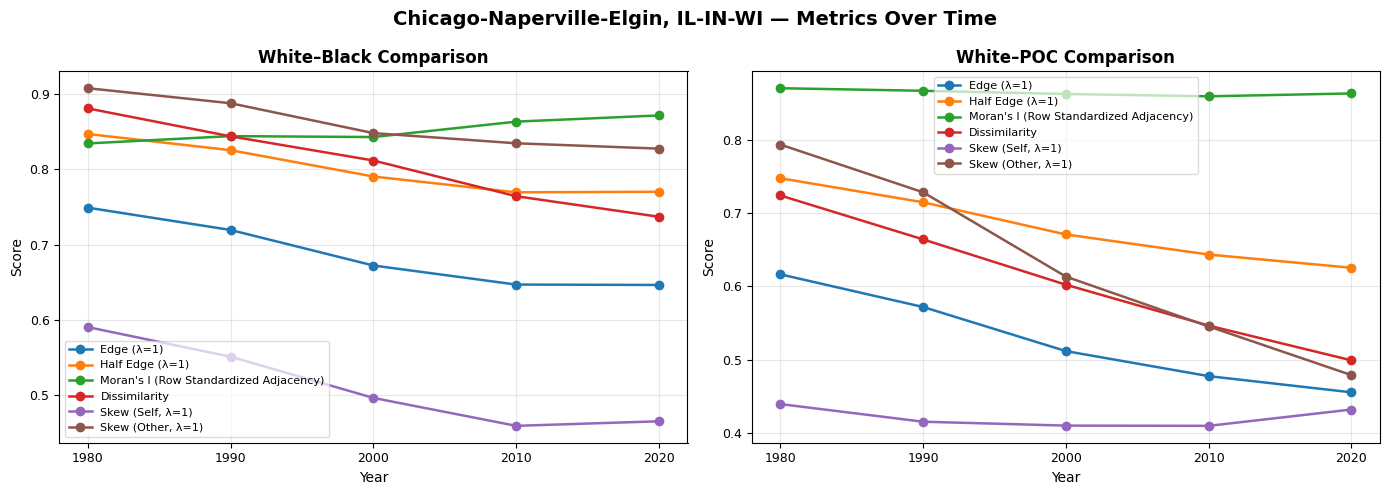


White–Black Comparison
  Year           edge_1      half_edge_1          moran_P  dissimilarity_1      skew_self_1     skew_other_1
------------------------------------------------------------------------------------------------------------
  1980           0.7490           0.8470           0.8345           0.8811           0.5902           0.9079
  1990           0.7193           0.8255           0.8442           0.8439           0.5508           0.8879
  2000           0.6721           0.7905           0.8430           0.8118           0.4960           0.8482
  2010           0.6468           0.7695           0.8635           0.7643           0.4588           0.8347
  2020           0.6462           0.7702           0.8717           0.7369           0.4649           0.8276
------------------------------------------------------------------------------------------------------------
  Mean           0.6867           0.8005           0.8514           0.8076           0.5121           0.

In [9]:
metrics = ["edge_1", "half_edge_1", "moran_P", "dissimilarity_1", "skew_self_1", "skew_other_1"]

plot_score_graph(CBSA, metrics)